# Reanalysis climatology

In [1]:
import sys
import os
import glob
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.gridspec import GridSpec
sys.path.append('/g/data/qz03/wp3/users/jb6465/code/git-repo')
from utils import *

In [2]:
import warnings
import logging
warnings.filterwarnings('ignore') 
logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)
logging.getLogger('flox').setLevel(logging.WARNING)

In [3]:
import dask
import tempfile
from dask.diagnostics import ProgressBar
from dask.distributed import Client, LocalCluster

dask.config.set({
    'array.chunk-size': "256 MiB",
    'array.slicing.split_large_chunks': True, #This can make AXIOM very slow
    'distributed.comm.timeouts.connect': '120s',
    'distributed.comm.timeouts.tcp': '120s',
    'distributed.comm.retry.count': 10,
    'distributed.scheduler.allowed-failures': 20,
    "distributed.scheduler.worker-saturation": 1.1, #This should use the new behaviour which helps with memory pile up
})

# client = dask.distributed.Client()
client = Client(n_workers=10, threads_per_worker=1, local_directory = tempfile.mkdtemp(), memory_limit = "63000mb")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 10
Total threads: 10,Total memory: 586.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44209,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44633,Total threads: 1
Dashboard: /proxy/46205/status,Memory: 58.67 GiB
Nanny: tcp://127.0.0.1:35479,


## Load in reanalysis grids

In [4]:
%%time
barra_uas_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/1hr/uas/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')
barra_vas_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/1hr/vas/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')
barra_u100_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/1hr/ua100m/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')
barra_v100_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/1hr/va100m/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')
barra_pr_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/1hr/pr/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')
barra_rsds_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/1hr/rsds/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')
barra_rsds_dly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/BARRAR2/day/rsds/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4')

era5_uas_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/ERA5/10u/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_vas_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/ERA5/10v/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_u100_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/ERA5/100u/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_v100_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/ERA5/100v/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_pr_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/ERA5/tp/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})
era5_rsds_hly = xr.open_mfdataset(glob.glob('/g/data/qz03/wp3/data/bmkg/reanalysis/ERA5/ssrd/*.nc'),combine='nested', concat_dim='time',parallel=True, engine='netcdf4').rename({'latitude': 'lat'}).rename({'longitude': 'lon'})


CPU times: user 10.4 s, sys: 2.16 s, total: 12.6 s
Wall time: 27.6 s


### Windspeed climatologies

In [5]:
def plot_climo(plot_type, input_climo_xr, plot_var, cmap, vmin, vmax, cbar_extend, cbar_label, plot_title):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    sys.path.append('/g/data/qz03/wp3/users/jb6465/code/git-repo')
    from utils import domain_dict
    
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    plot_array = input_climo_xr[plot_var]
    
    contour = plot_array.plot.imshow(ax=ax, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), cmap=cmap, add_colorbar=False) if plot_type =='raster' else plot_array.plot.contourf(ax=ax, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), cmap=cmap, levels=((vmax-vmin)*2)+1, add_colorbar=False)
    cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, fraction=0.07, shrink=0.6, extend=cbar_extend, label=cbar_label)
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(plot_title, fontsize=14, pad=12)
    ax.set_extent([domain_dict['indonesia']['lon_min'], domain_dict['indonesia']['lon_max'], domain_dict['indonesia']['lat_min'], domain_dict['indonesia']['lat_max']], crs=ccrs.PlateCarree())
    
    plt.tight_layout()
    plt.show()
    return

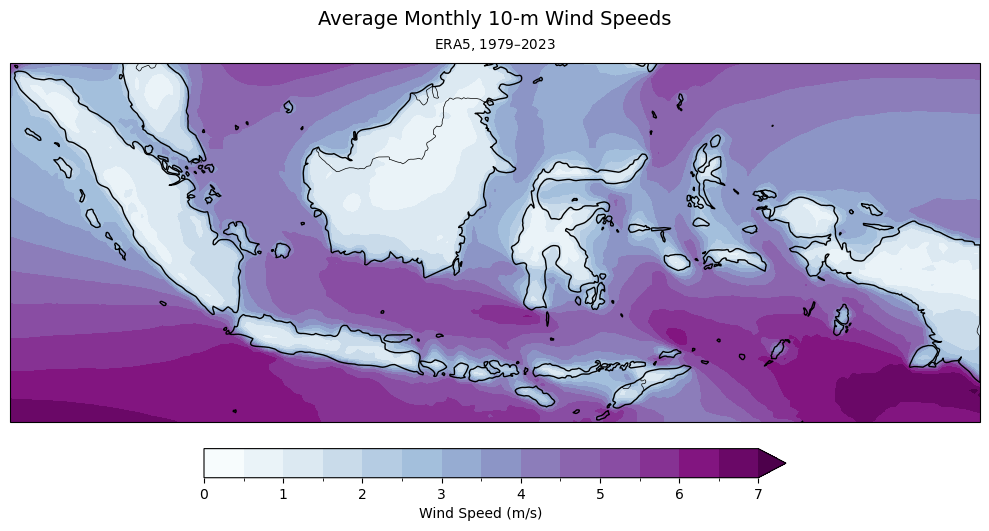

CPU times: user 1min 27s, sys: 7.18 s, total: 1min 35s
Wall time: 2min 2s


In [6]:
%%time
era5_ws10_hly = (era5_vas_hly.v10**2 + era5_uas_hly.u10**2) ** 0.5
era5_ws10_dly = (era5_ws10_hly.sortby("time")).resample(time='D').mean()
era5_ws10_dly = era5_ws10_dly.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()
plot_climo('contour', xr.Dataset({'ws10': ((era5_ws10_dly.resample(time='1M')).mean()).mean(dim='time')}), 'ws10', 'BuPu', 0, 7, 'max', 'Wind Speed (m/s)', 'Average Monthly 10-m Wind Speeds\n$_{\\text{ERA5, 1979–2023}}$')

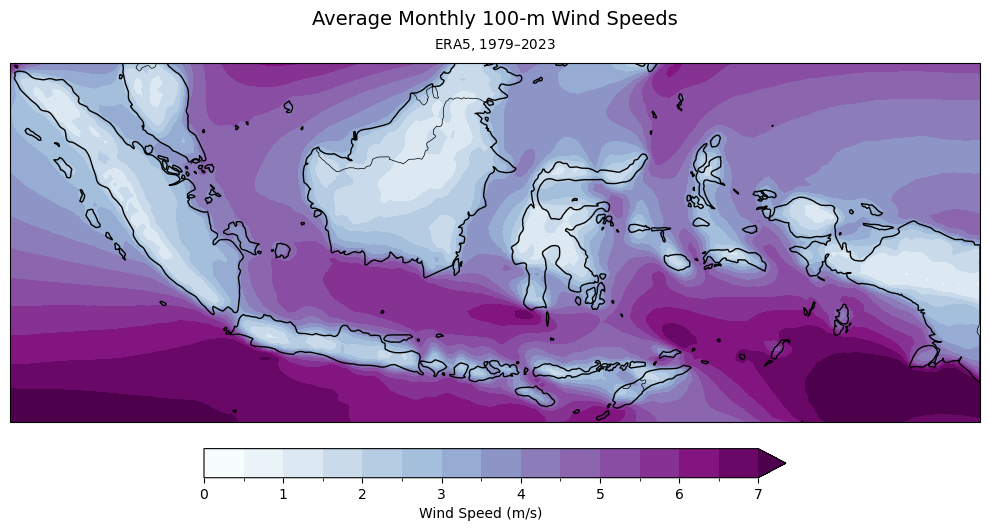

CPU times: user 1min 53s, sys: 9.72 s, total: 2min 3s
Wall time: 4min 9s


In [7]:
%%time
era5_ws100_hly = (era5_v100_hly.v100**2 + era5_u100_hly.u100**2) ** 0.5
era5_ws100_dly = (era5_ws100_hly.sortby("time")).resample(time='D').mean()
era5_ws100_dly = era5_ws100_dly.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()
plot_climo('contour', xr.Dataset({'ws100': ((era5_ws100_dly.resample(time='1M')).mean()).mean(dim='time')}), 'ws100', 'BuPu', 0, 7, 'max', 'Wind Speed (m/s)', 'Average Monthly 100-m Wind Speeds\n$_{\\text{ERA5, 1979–2023}}$')

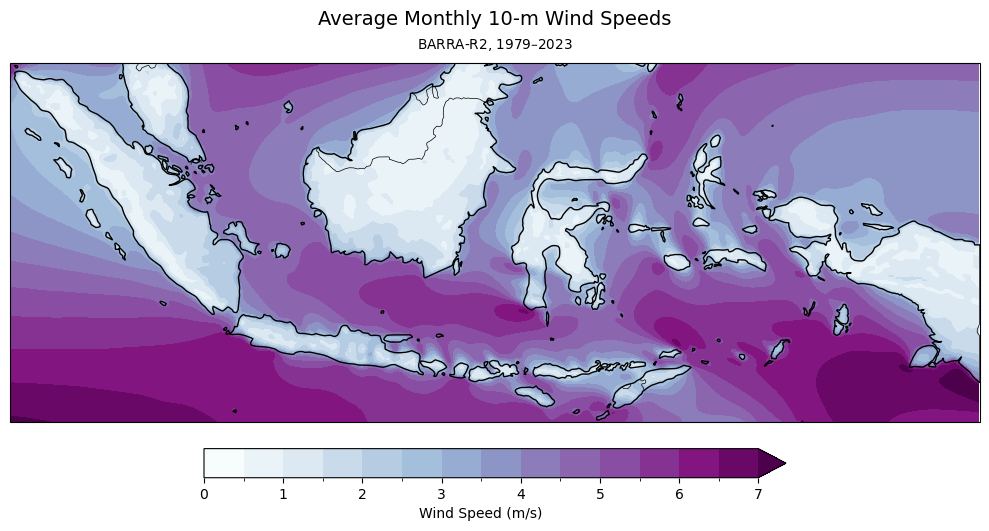

CPU times: user 17min 22s, sys: 7min 35s, total: 24min 57s
Wall time: 1h 16min 8s


In [8]:
%%time
barra_ws10_hly = (barra_vas_hly.sortby("time").vas**2 + barra_uas_hly.sortby("time").uas**2) ** 0.5
barra_ws10_dly = (barra_ws10_hly.sortby("time")).resample(time='D').mean()
barra_ws10_dly = barra_ws10_dly.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()
plot_climo('contour', xr.Dataset({'ws10': ((barra_ws10_dly.resample(time='1M')).mean()).mean(dim='time')}), 'ws10', 'BuPu', 0, 7, 'max', 'Wind Speed (m/s)', 'Average Monthly 10-m Wind Speeds\n$_{\\text{BARRA-R2, 1979–2023}}$')

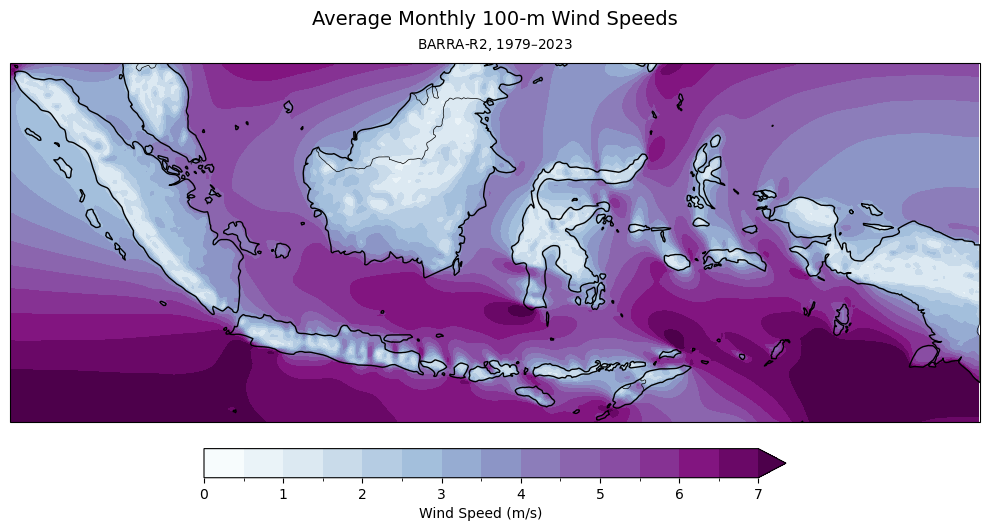

CPU times: user 23min 58s, sys: 9min 2s, total: 33min
Wall time: 1h 47min 47s


In [6]:
%%time
barra_ws100_hly = (barra_v100_hly.sortby("time").va100m**2 + barra_u100_hly.sortby("time").ua100m**2) ** 0.5
barra_ws100_dly = (barra_ws100_hly.sortby("time")).resample(time='D').mean()
barra_ws100_dly = barra_ws100_dly.chunk({'time':720, 'lat':'auto', 'lon':'auto'}).compute()
barra_ws100_mthly = xr.Dataset({'ws100': ((barra_ws100_dly.resample(time='1M')).mean()).mean(dim='time')})

plot_climo('contour', xr.Dataset({'ws100': ((barra_ws100_dly.resample(time='1M')).mean()).mean(dim='time')}), 'ws100', 'BuPu', 0, 7, 'max', 'Wind Speed (m/s)', 'Average Monthly 100-m Wind Speeds\n$_{\\text{BARRA-R2, 1979–2023}}$')

### Multiplots

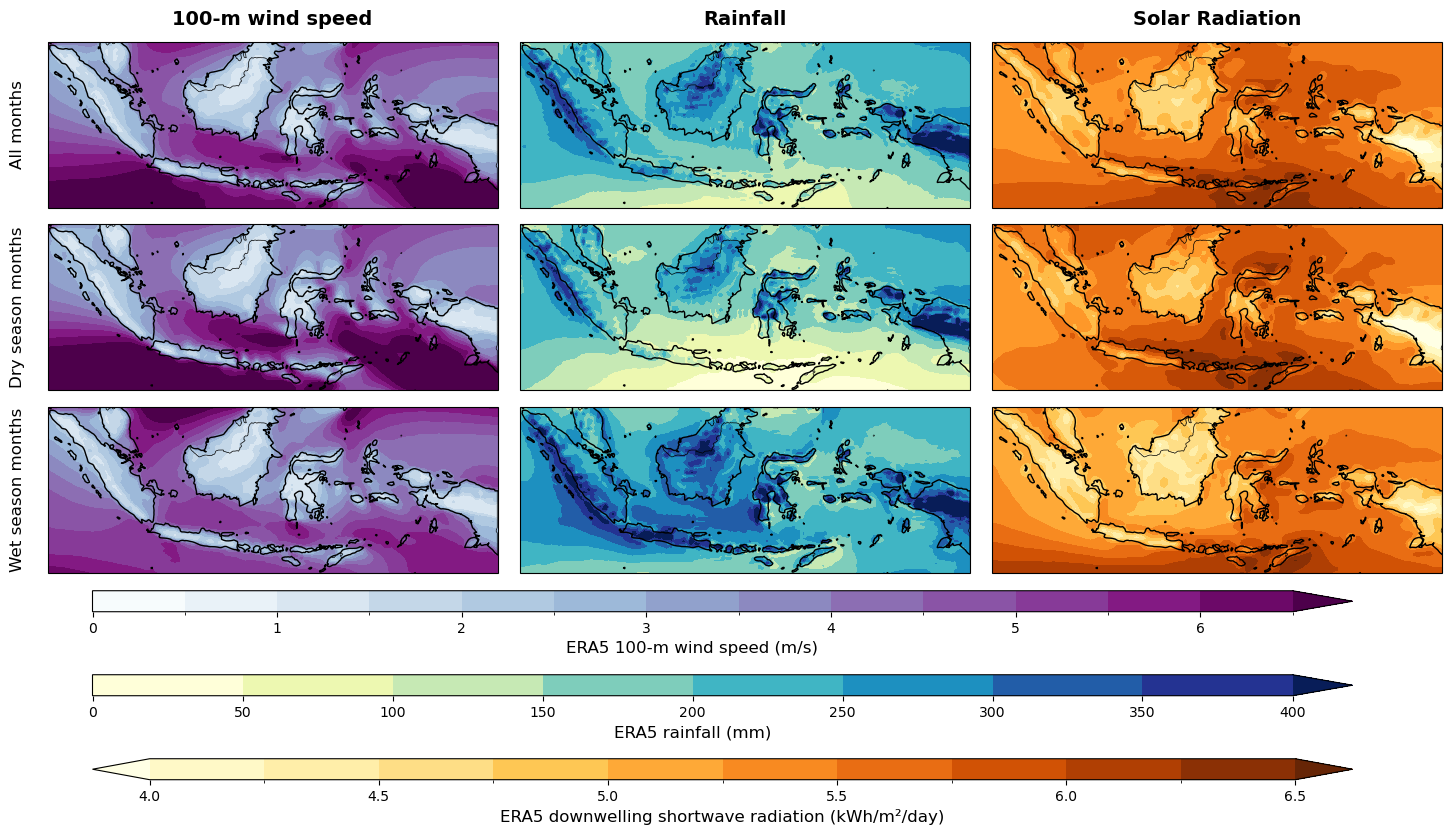

<Figure size 640x480 with 0 Axes>

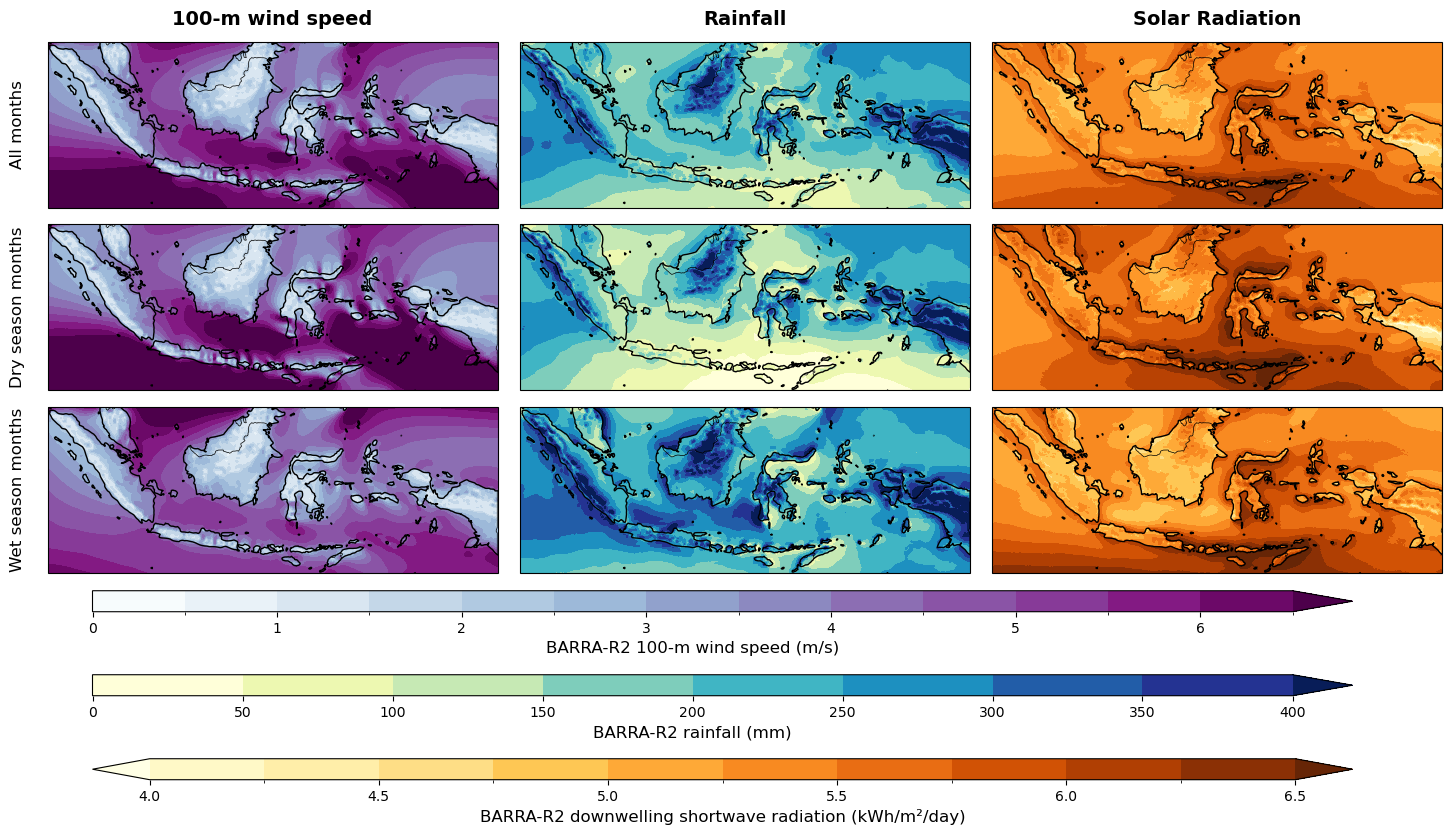

CPU times: user 23min 32s, sys: 1min 50s, total: 25min 23s
Wall time: 34min 30s


<Figure size 640x480 with 0 Axes>

In [15]:
%%time
for plot_source in ['ERA5', 'BARRA-R2']:
    ws10 = xr.Dataset({'ws10': (barra_ws10_hly.sortby("time").resample(time='1M')).mean()}) if plot_source == 'BARRA-R2' else xr.Dataset({'ws10': (((era5_vas_hly.v10**2 + era5_uas_hly.u10**2) ** 0.5).sortby("time").resample(time='1M')).mean()})
    ws100 = xr.Dataset({'ws100': (barra_ws100_hly.sortby("time").resample(time='1M')).mean()}) if plot_source == 'BARRA-R2' else xr.Dataset({'ws100': (((era5_v100_hly.v100**2 + era5_u100_hly.u100**2) ** 0.5).sortby("time").resample(time='1M')).mean()})
    pr = xr.Dataset({'pr': (barra_pr_hly.pr.sortby("time")*3600).resample(time='1M').sum()}) if plot_source == 'BARRA-R2' else xr.Dataset({'pr': (era5_pr_hly.tp.sortby("time")*1000).resample(time='1M').sum()}) 
    ghi = xr.Dataset({'ghi': ((barra_rsds_dly.rsds*0.024).sortby('time'))}) if plot_source == 'BARRA-R2' else xr.Dataset({'ghi': (era5_rsds_hly.ssrd.sortby("time")/(3.6e6)).resample(time='D').sum()}) #GHI units = kWh/m2 BARRA units = W/m2 #ERA5 units = J/m2
    
    climo_dict = {}
    climo_dict['All_months-100-m_winds'] = ws100.mean(dim='time')
    climo_dict['Dry_season_months-100-m_winds'] = ws100.sel(time=ws100.time.dt.month.isin([4, 5, 6, 7, 8, 9, 10])).mean('time')
    climo_dict['Wet_season_months-100-m_winds'] = ws100.sel(time=ws100.time.dt.month.isin([11, 12, 1, 2, 3])).mean('time')

    # climo_dict['All_months-10-m_winds'] = ws10.mean(dim='time')
    # climo_dict['Dry_season_months-10-m_winds'] = ws10.sel(time=ws10.time.dt.month.isin([4, 5, 6, 7, 8, 9, 10])).mean('time')
    # climo_dict['Wet_season_months-10-m_winds'] = ws10.sel(time=ws10.time.dt.month.isin([11, 12, 1, 2, 3])).mean('time')

    climo_dict['All_months_months-rainfall'] = pr.mean(dim='time')
    climo_dict['Dry_season_months-rainfall'] = pr.sel(time=pr.time.dt.month.isin([4, 5, 6, 7, 8, 9, 10])).mean('time')
    climo_dict['Wet_season_months-rainfall'] = pr.sel(time=pr.time.dt.month.isin([11, 12, 1, 2, 3])).mean('time')
    
    climo_dict['All_months-surface_downwelling_radiation'] = ghi.mean(dim='time')
    climo_dict['Dry_season_months-surface_downwelling_radiation'] = ghi.sel(time=ghi.time.dt.month.isin([4, 5, 6, 7, 8, 9, 10])).mean('time')
    climo_dict['Wet_season_months-surface_downwelling_radiation'] = ghi.sel(time=ghi.time.dt.month.isin([11, 12, 1, 2, 3])).mean('time')

    fig = plt.figure(figsize=(18, 7))
    gs = GridSpec(3, 3, figure=fig, hspace=0.05, wspace=0.05)
    axes = [fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree()) for i in range(3) for j in range(3)]
    
    season_order = ['All_months', 'Dry_season_months', 'Wet_season_months']
    var_order = ['100-m_winds', 'rainfall', 'surface_downwelling_radiation']
    ordered_keys = []
    for season in season_order:
        for var in var_order:
            for key in climo_dict.keys():
                if season in key and var in key:
                    ordered_keys.append(key)

    for ax, key in zip(axes, ordered_keys):
        plot_data = climo_dict[key]

        if '100-m_winds' in key:
            wind100m = plot_data.ws100.plot.contourf(ax=ax, vmin=0, vmax=6.5, levels=14, transform=ccrs.PlateCarree(), cmap='BuPu', add_colorbar=False)    
        elif 'rainfall' in key:
            rain = plot_data.pr.plot.contourf(ax=ax, vmin=0, vmax=400, levels=9, transform=ccrs.PlateCarree(), cmap='YlGnBu', add_colorbar=False)    
        elif 'radiation' in key:
            rsds = plot_data.ghi.plot.contourf(ax=ax, vmin=4, vmax=6.5, levels=11, transform=ccrs.PlateCarree(), cmap='YlOrBr', add_colorbar=False)    
    
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_extent([domain_dict['indonesia']['lon_min'], domain_dict['indonesia']['lon_max'],
                       domain_dict['indonesia']['lat_min'], domain_dict['indonesia']['lat_max']], crs=ccrs.PlateCarree())
        ax.set_title('')

    col_labels = ['100-m wind speed', 'Rainfall', 'Solar Radiation']
    for j in range(3):
        axes[j].set_title(col_labels[j], fontsize=14, pad=12, fontweight='bold')


    row_labels = ['All months', 'Dry season months', 'Wet season months']
    for i in range(3):
        ax = axes[i * 3]
        ax.text(-0.05, 0.5, row_labels[i], va='center', ha='right', rotation=90,
                fontsize=12, transform=ax.transAxes)

    cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.03])  
    cbar = fig.colorbar(wind100m, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(f"{plot_source} 100-m wind speed (m/s)", fontsize=12)
    
    cbar_ax = fig.add_axes([0.15, -0.06, 0.7, 0.03])  
    cbar = fig.colorbar(rain, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(f"{plot_source} rainfall (mm)", fontsize=12)
    
    cbar_ax = fig.add_axes([0.15, -0.18, 0.7, 0.03])   
    cbar = fig.colorbar(rsds, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(f"{plot_source} downwelling shortwave radiation (kWh/m²/day)", fontsize=12)
    
    plt.show()
    plt.clf()

### Timeseries plots

In [16]:
loc_data = ((barra_ws10_hly.resample(time='D')).mean()).sel(lat=-6.830714, lon=105.285399, method='nearest').sortby('time').compute() 
#sidrap .sel(lat=-3.9873, lon=119.7115, method='nearest').sortby('time').compute() 
#tolo .sel(lat=-5.645031, lon=119.711252, method='nearest').sortby('time').compute() 
#western Banten Province .sel(lat=-6.830714, lon=105.285399, method='nearest').sortby('time').compute() 

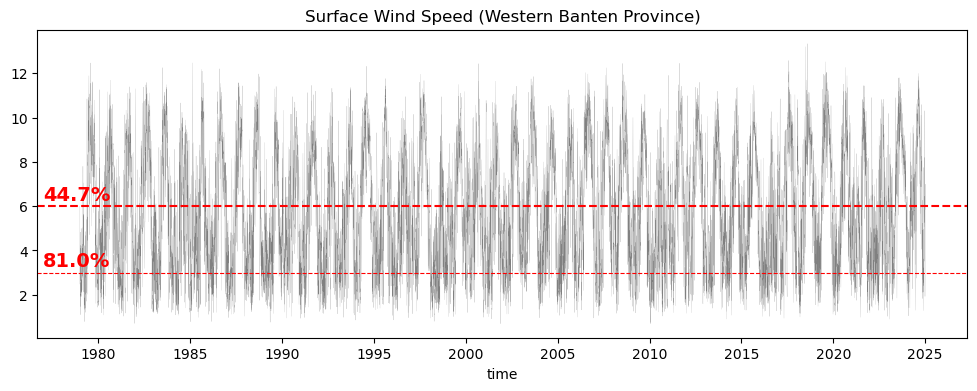

In [17]:
ax = loc_data.plot.line(color='grey', figsize=(12, 4), linewidth=0.1)
plt.title('Surface Wind Speed (Western Banten Province)')

time_above_3 = 100*((loc_data > 3).sum().item())/(loc_data.shape[0])
time_above_6 = 100*((loc_data > 6).sum().item())/(loc_data.shape[0])

plt.text(np.datetime64('1977-01-01'), 3.1, f"{time_above_3:.1f}%", color='red', fontweight='bold', fontsize=14, va='bottom')
plt.text(np.datetime64('1977-01-01'), 6.1, f"{time_above_6:.1f}%", color='red', fontweight='bold', fontsize=14, va='bottom')

plt.axhline(y=3, color='red', linestyle='--', linewidth=0.8)
plt.axhline(y=6, color='red', linestyle='--')
plt.show()